CIND820: Big Data Analytics Project 
Insurance Fraud Detection using Machine Learning on Past Claims Data 
Abdullah Shaban
Student ID:
Supervisor:
Date: 2026-07-01

In [150]:
#Importing all the libraries we will use

import pandas as pd
import numpy as np
import pathlib
import matplotlib.pyplot as plt
import seaborn as sns

In [151]:
#Loading the Dataset
df=pd.read_csv("fraud_oracle.csv")

**Exploratory Data Analysis**

In [152]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [153]:
#size of the dataset
df.shape

(15420, 33)

Our dataset has 15420 rows and 33 colums

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

As it can be seen above we do not have any missing values in our dataset, if missing values were present they can be replaced
with either mean, median or omitted based on the outcome that better serves our model

In [155]:
#Variable Type breakdown and count
df.dtypes.value_counts()

object    24
int64      9
Name: count, dtype: int64

In total we have 33 columns out of which 24 are categorical and 9 are numerical

In [156]:
#list of categorical variables
df.columns[df.dtypes==object]

Index(['Month', 'DayOfWeek', 'Make', 'AccidentArea', 'DayOfWeekClaimed',
       'MonthClaimed', 'Sex', 'MaritalStatus', 'Fault', 'PolicyType',
       'VehicleCategory', 'VehiclePrice', 'Days_Policy_Accident',
       'Days_Policy_Claim', 'PastNumberOfClaims', 'AgeOfVehicle',
       'AgeOfPolicyHolder', 'PoliceReportFiled', 'WitnessPresent', 'AgentType',
       'NumberOfSuppliments', 'AddressChange_Claim', 'NumberOfCars',
       'BasePolicy'],
      dtype='object')

In [157]:
#list of numerical variables
df.columns[df.dtypes=='int64']

Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'Age', 'FraudFound_P',
       'PolicyNumber', 'RepNumber', 'Deductible', 'DriverRating', 'Year'],
      dtype='object')

Our dataset is highly imbalanced with majority of the cases are gunine and only a very small percentage of fraud cases are 
present in our dataset, lets see the breakdown of fraud vs non fraud cases

In [158]:
df.rename(columns={'FraudFound_P': 'FraudFound'}, inplace=True)
fraud_cases = pd.DataFrame(df['FraudFound'].value_counts())
fraud_cases['Percentage'] = round(df['FraudFound'].value_counts(normalize=True) * 100, 2)
fraud_cases = fraud_cases.rename(columns={'FraudFound': 'Claims'})
fraud_cases

,count,Percentage
FraudFound,,
0,14497,94.01
1,923,5.99


Only 5.99%  of cases are fraud in our dataset which represents a highly imbalanced dataset, we will use various techniques 
later during our model development to deal with the class imbalance problem

Imbalanced Data Visualization

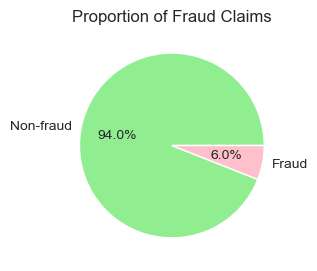

In [159]:
fig, ax = plt.subplots(figsize=(4, 3))
fraud_proportion = df['FraudFound'].value_counts(normalize=True)
fraud_proportion.plot.pie(labels=['Non-fraud', 'Fraud'], autopct='%1.1f%%', ax=ax, colors=['lightgreen', 'pink'])  # Specify the axis using ax=ax

# Remove y-axis label
ax.set_ylabel('')

plt.title('Proportion of Fraud Claims')
plt.show()

**Overview of the Variables:**
Number of variables
In total, there are 33 variables:
32 input variables
1 Output Variable

Data Types
Numeric (int64) - 9
Binary (Object) - 24

Target Variable
FraudFound
Numeric
Binary (0/1)

Class Distribution: imbalanced (6% Fraud vs 94% Non-fraud)

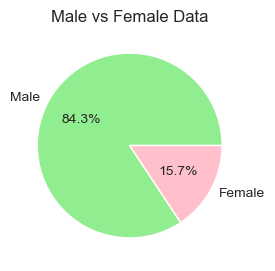

In [160]:
#lets see how many males vs females candidates are present in our dataset
Sex = df['Sex'].value_counts()
fig, ax = plt.subplots(figsize=(4, 3))
labels = ['Male', 'Female']
ax.pie(Sex, labels=labels, autopct='%1.1f%%', colors=['lightgreen', 'pink'])

plt.title('Male vs Female Data')
plt.show()

Gender distribution in Fraud Cases

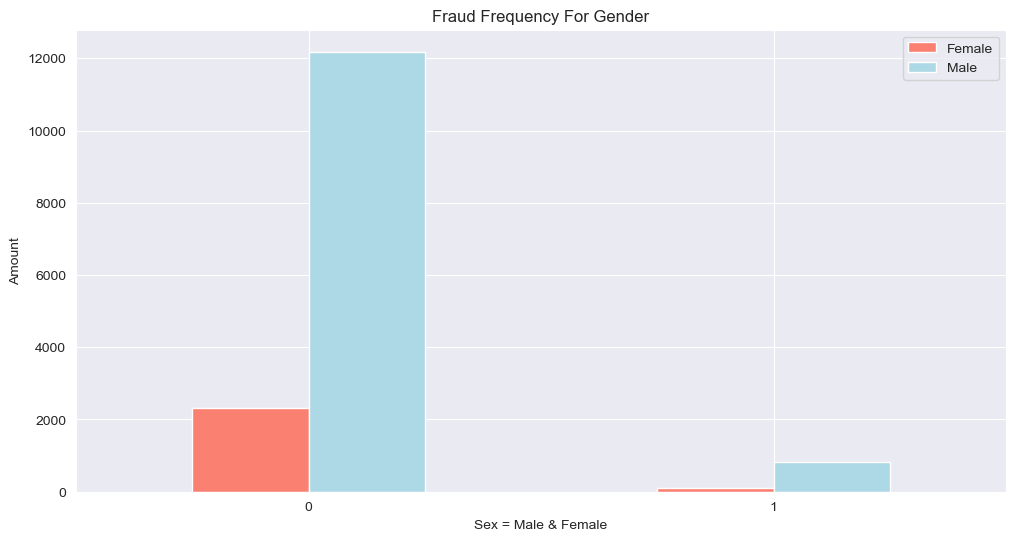

In [161]:
# Create a plot of crosstab for FraudFound and Sex Columns
pd.crosstab(df.FraudFound, df.Sex).plot(kind="bar",
                                          color=["salmon","lightblue"],
                                          figsize=(12,6))

plt.title("Fraud Frequency For Gender")
plt.xlabel("Sex = Male & Female")
plt.ylabel("Amount")
plt.legend(["Female","Male"])
plt.xticks(rotation = 0);

In [162]:
df['Age'].describe()

count    15420.000000
mean        39.855707
std         13.492377
min          0.000000
25%         31.000000
50%         38.000000
75%         48.000000
max         80.000000
Name: Age, dtype: float64

Distribution of Age in Fraud and Legitimate Cases

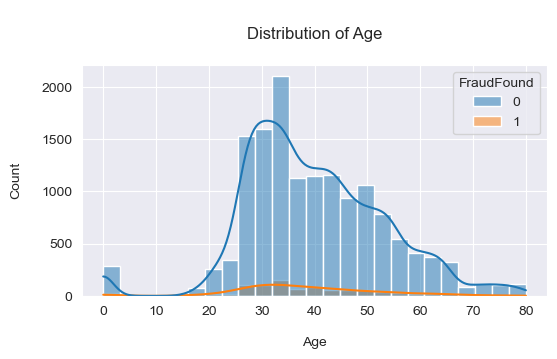

In [163]:
# Plot the distribution:
plt.figure(figsize=(6, 3))
sns.set_style('darkgrid')
sns.histplot(data=df, x='Age', color='teal', kde=True, bins=25, hue='FraudFound')
plt.title('\nDistribution of Age\n')
plt.xlabel('\nAge')
plt.ylabel('Count\n')
plt.show()

In [164]:
# We have a total of 320 cases where Age = 0. 31 of them are Fraud vases vs 289 non-Fraud cases.
# Need to replace Age values that are currently 0. First replace them with NaN, than impute with median for Age for FraudFound == 0:

df['Age'] = df['Age'].replace(0, float('nan'))

# Calculate the median of 'Age' for non-fraudulent cases
median_age_non_fraud = df[df['FraudFound'] == 0]['Age'].median()

# Fill NaN values in 'Age' with the calculated median
df['Age'].fillna(median_age_non_fraud, inplace=True)

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\3505643214.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age_non_fraud, inplace=True)


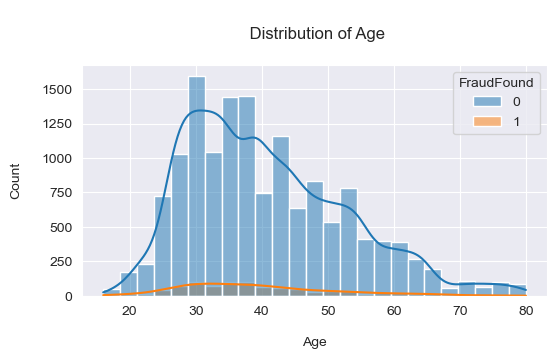

In [165]:
# Replot the distribution:
plt.figure(figsize=(6, 3))
sns.set_style('darkgrid')
sns.histplot(data=df, x='Age', color='teal', kde=True, bins=25, hue='FraudFound')
plt.title('\n Distribution of Age\n')
plt.xlabel('\nAge')
plt.ylabel('Count\n')
plt.show()

Lets Analyze which month of the year has highest number of fraud accidents

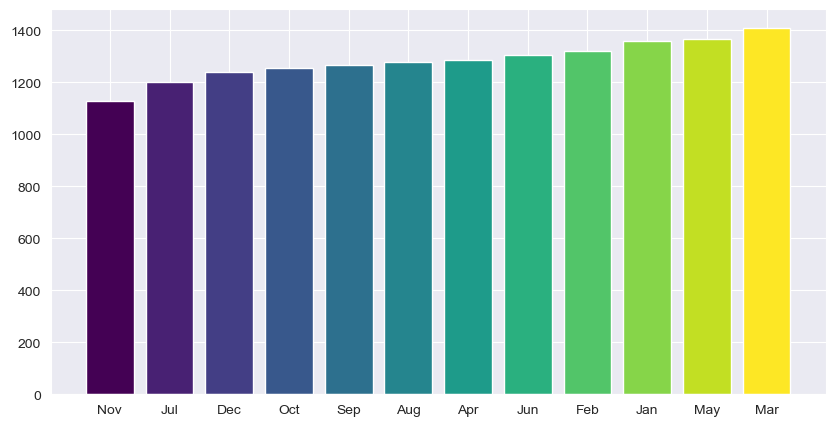

In [166]:
Months_list=['Nov','Jul','Dec','Oct','Sep','Aug','Apr','Jun','Feb','Jan','May','Mar']
colors = plt.cm.viridis(np.linspace(0, 1, len(Months_list)))

plt.figure(figsize=(10,5))
plt.bar(
    Months_list,
    df.groupby('Month').count()['FraudFound'].sort_values(),
    color=colors
)

plt.show()

As it can be seen in the bar chart above that March has the highest concentration of fraud accidents

Lets Explore which day of the week has highest number of accidents

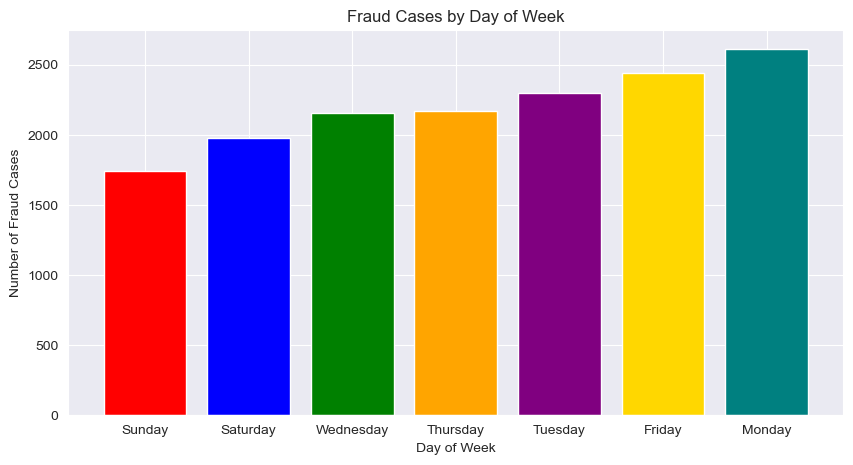

In [167]:

Days_list = ['Sunday', 'Saturday', 'Wednesday', 'Thursday', 'Tuesday', 'Friday', 'Monday']

colors = ['red', 'blue', 'green', 'orange', 'purple', 'gold', 'teal']

plt.figure(figsize=(10,5))
plt.bar(
    Days_list,
    df.groupby('DayOfWeek').count()['FraudFound'].sort_values(),
    color=colors
)

plt.xlabel('Day of Week')
plt.ylabel('Number of Fraud Cases')
plt.title('Fraud Cases by Day of Week')

plt.show()

As it can be seen in the bar chart above that Monday has the highest concentration of fraud accidents

Lets analyze which vehicle makes are most involved in the accidents

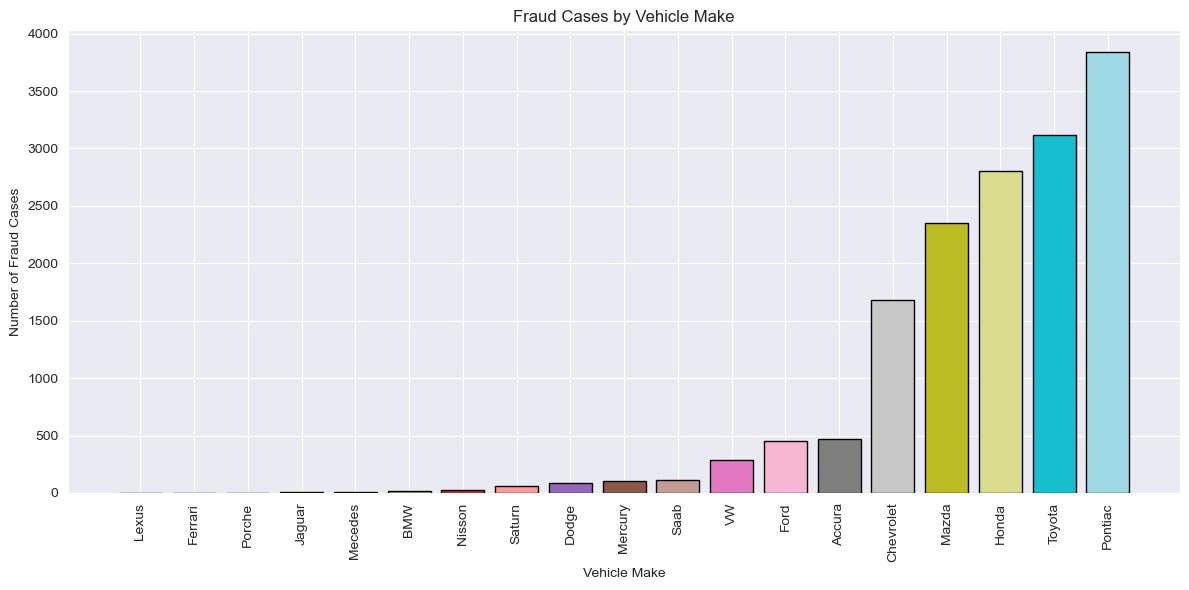

In [168]:
Make_list = [
    'Lexus', 'Ferrari', 'Porche', 'Jaguar', 'Mecedes', 'BMW', 'Nisson',
    'Saturn', 'Dodge', 'Mercury', 'Saab', 'VW', 'Ford', 'Accura',
    'Chevrolet', 'Mazda', 'Honda', 'Toyota', 'Pontiac'
]

colors = plt.cm.tab20(np.linspace(0, 1, len(Make_list)))

plt.figure(figsize=(12,6))

plt.bar(
    Make_list,
    df.groupby('Make').count()['FraudFound'].sort_values(),
    color=colors,
    edgecolor='black'
)

plt.xticks(rotation=90)
plt.xlabel('Vehicle Make')
plt.ylabel('Number of Fraud Cases')
plt.title('Fraud Cases by Vehicle Make')

plt.tight_layout()
plt.show()

By analyzing above charts we noticed that 'Pontiac' make vehicles had more accidents

Lets compare accident ratio in Rural vs Urban Areas

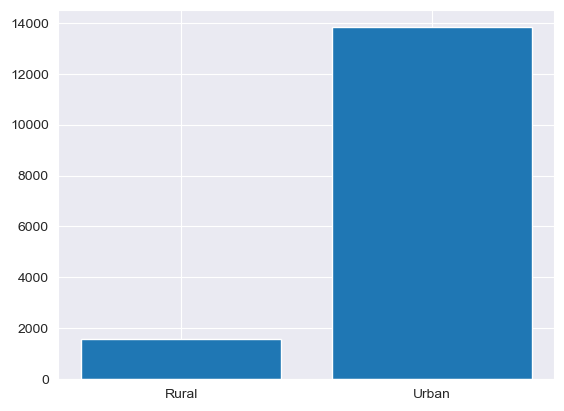

In [169]:
plt.bar(['Rural','Urban'],df.groupby('AccidentArea').count()['FraudFound'].sort_values())
plt.show()

Most of the accidents happend in rural urban areas, insurance companies can conduct roadsafety campains in Urban areas
and introduce initiatives and generous discounts to Urban drivers with no accident history


Fraud Cases Distribution by Age

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\1188290065.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  grph =sns.barplot(x='Age', y='FraudFound', data = gpd_by_val, ax=ax1, palette='magma' )
C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\1188290065.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  grph.set_xticklabels(grph.get_xticklabels(),


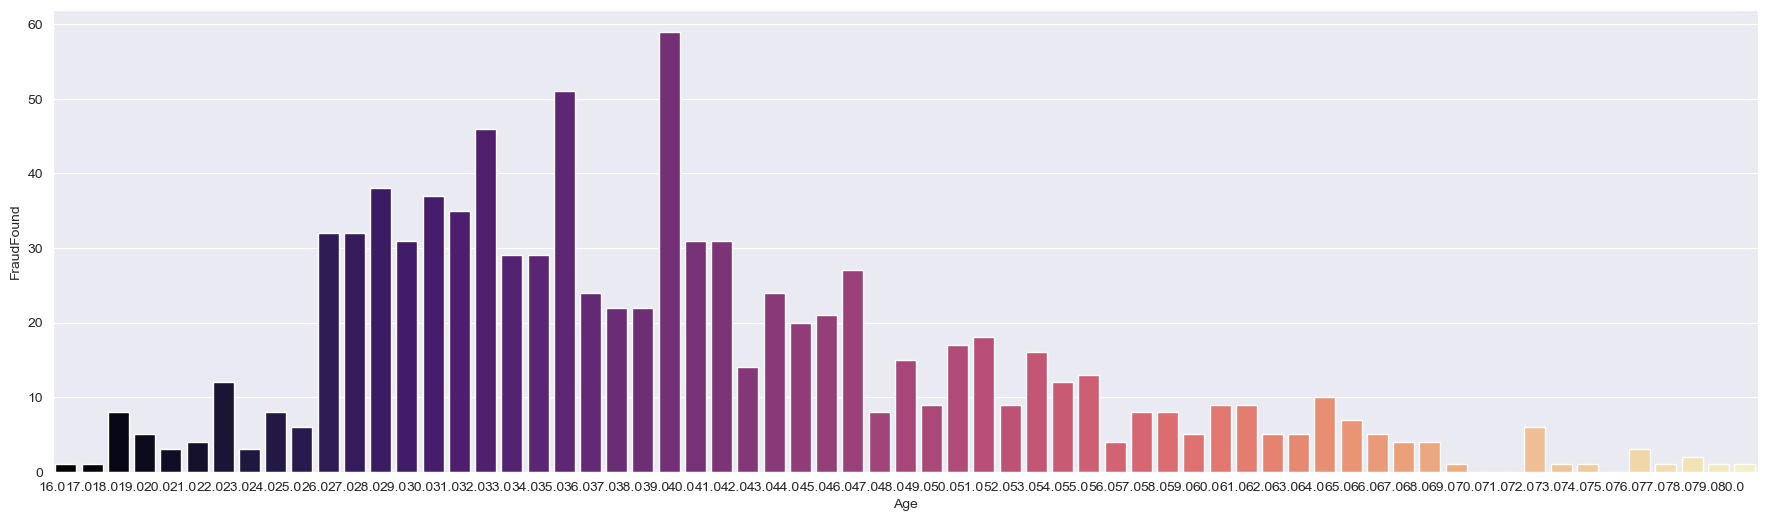

In [170]:
# Let's check FraudFound with Age using barplot
gpd_by_val=df.groupby('Age').agg({'FraudFound':'sum'}).reset_index()

fig, (ax1) = plt.subplots(1,1,figsize=(22, 6))
grph =sns.barplot(x='Age', y='FraudFound', data = gpd_by_val, ax=ax1, palette='magma' )

grph.set_xticklabels(grph.get_xticklabels(),
                    rotation=0,
                    horizontalalignment='right');


C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\162262442.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgentType', y='FraudFound', data = gpd_val1, ax=ax1, palette='magma')
C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\162262442.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='FraudFound', data = gpd_val2, ax=ax2,palette='coolwarm')
C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\162262442.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Days_Policy_Accident', y='FraudFound', data = gpd_val3, ax=ax3, 

<Axes: xlabel='Days_Policy_Accident', ylabel='FraudFound'>

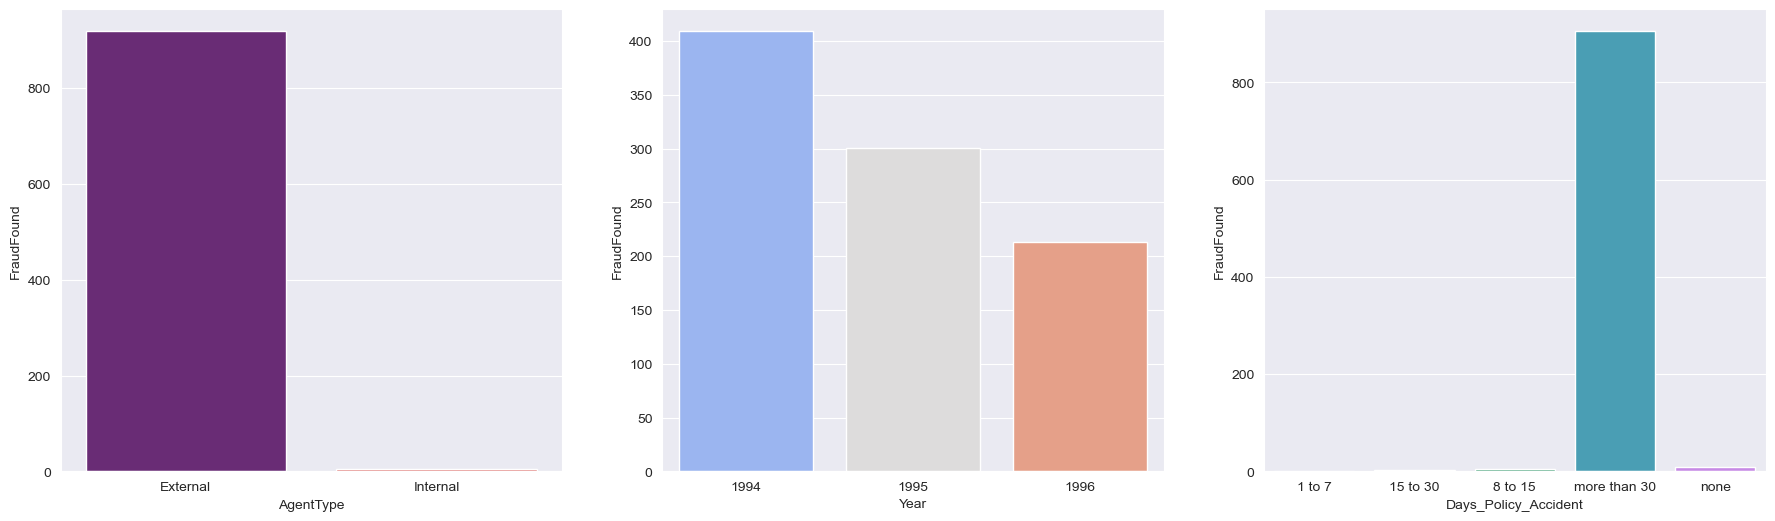

In [171]:
# Let's Check the AgentType, Year, and daysPolicy with FraudFound using barplot
gpd_val1=df.groupby('AgentType').agg({'FraudFound':'sum'}).reset_index()
gpd_val2=df.groupby('Year').agg({'FraudFound':'sum'}).reset_index()
gpd_val3=df.groupby('Days_Policy_Accident').agg({'FraudFound':'sum'}).reset_index()


fig, (ax1,ax2,ax3) = plt.subplots(1,3,figsize=(22, 6))
sns.barplot(x='AgentType', y='FraudFound', data = gpd_val1, ax=ax1, palette='magma')
sns.barplot(x='Year', y='FraudFound', data = gpd_val2, ax=ax2,palette='coolwarm')
sns.barplot(x='Days_Policy_Accident', y='FraudFound', data = gpd_val3, ax=ax3, palette='husl')

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\1636208663.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PoliceReportFiled', y='FraudFound', data = gpd_val4, ax=ax1,palette='Paired')
C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\1636208663.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Days_Policy_Claim', y='FraudFound', data = gpd_val5, ax=ax2,palette='coolwarm')


<Axes: xlabel='Days_Policy_Claim', ylabel='FraudFound'>

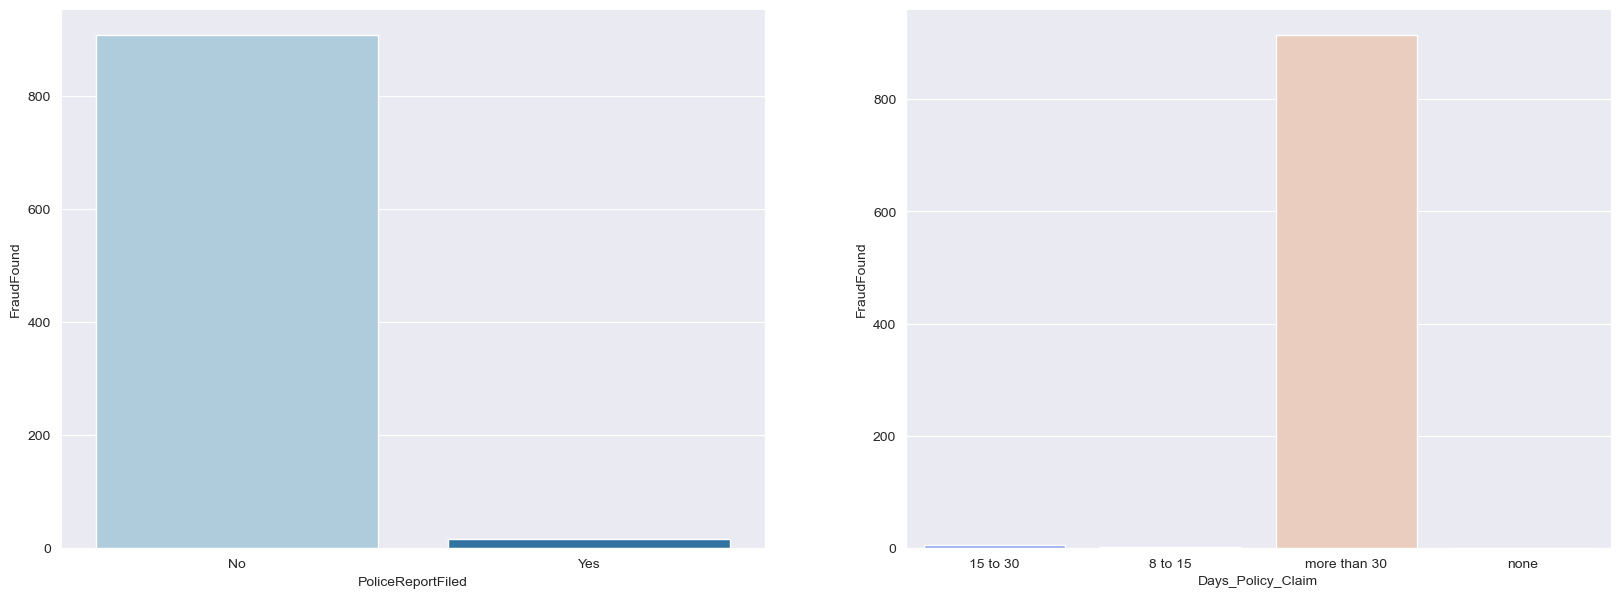

In [172]:
#Let's Plot the PoliceReportFiled, Days_Policy_Claim & DayOfWeek with FraudFound using Barplot
gpd_val4=df.groupby('PoliceReportFiled').agg({'FraudFound':'sum'}).reset_index()
gpd_val5=df.groupby('Days_Policy_Claim').agg({'FraudFound':'sum'}).reset_index()

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(20, 7))
sns.barplot(x='PoliceReportFiled', y='FraudFound', data = gpd_val4, ax=ax1,palette='Paired')
sns.barplot(x='Days_Policy_Claim', y='FraudFound', data = gpd_val5, ax=ax2,palette='coolwarm')

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\2706634923.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WeekOfMonthClaimed', y='FraudFound', data = gpd_val8, ax=ax1,palette='tab10')
C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\2706634923.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='DayOfWeekClaimed', y='FraudFound', data = gpd_val9, ax=ax2,palette='tab10')


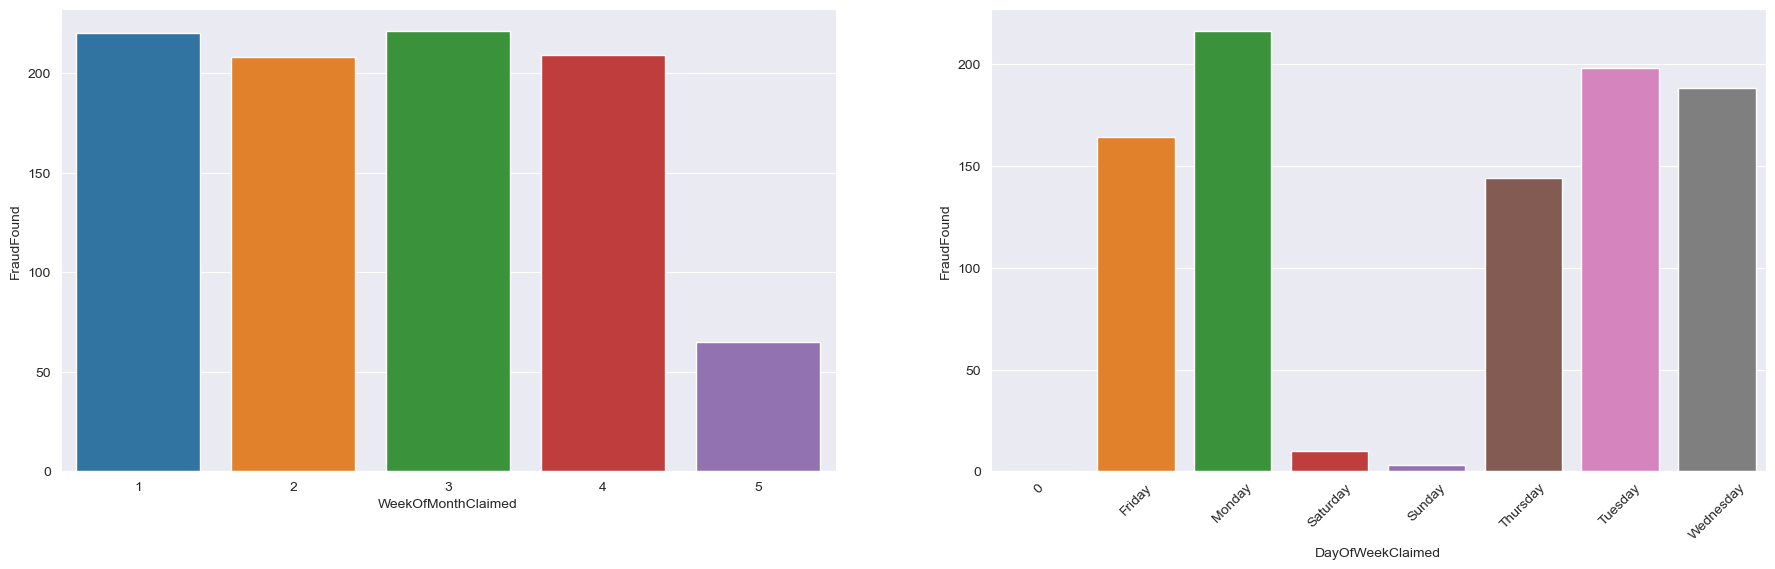

In [173]:
# Let's plot the WitnessPresent, WeekOfMonthClaimed & DayOFWeekClaimed with FraudFound using barplot
gpd_val8=df.groupby('WeekOfMonthClaimed').agg({'FraudFound':'sum'}).reset_index()
gpd_val9=df.groupby('DayOfWeekClaimed').agg({'FraudFound':'sum'}).reset_index()


fig, (ax1,ax2) = plt.subplots(1,2,figsize=(22, 6))
sns.barplot(x='WeekOfMonthClaimed', y='FraudFound', data = gpd_val8, ax=ax1,palette='tab10')
sns.barplot(x='DayOfWeekClaimed', y='FraudFound', data = gpd_val9, ax=ax2,palette='tab10')
plt.xticks(rotation=45);

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\544197179.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="DriverRating", y="FraudFound", data = gpd_val_10, ax= ax1,palette='tab10')
C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\544197179.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="NumberOfCars", y="FraudFound", data = gpd_val_11, ax= ax2,palette='tab20')
C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\544197179.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WitnessPresent', y='FraudFound', data = gpd_val_12, 

<Axes: xlabel='WitnessPresent', ylabel='FraudFound'>

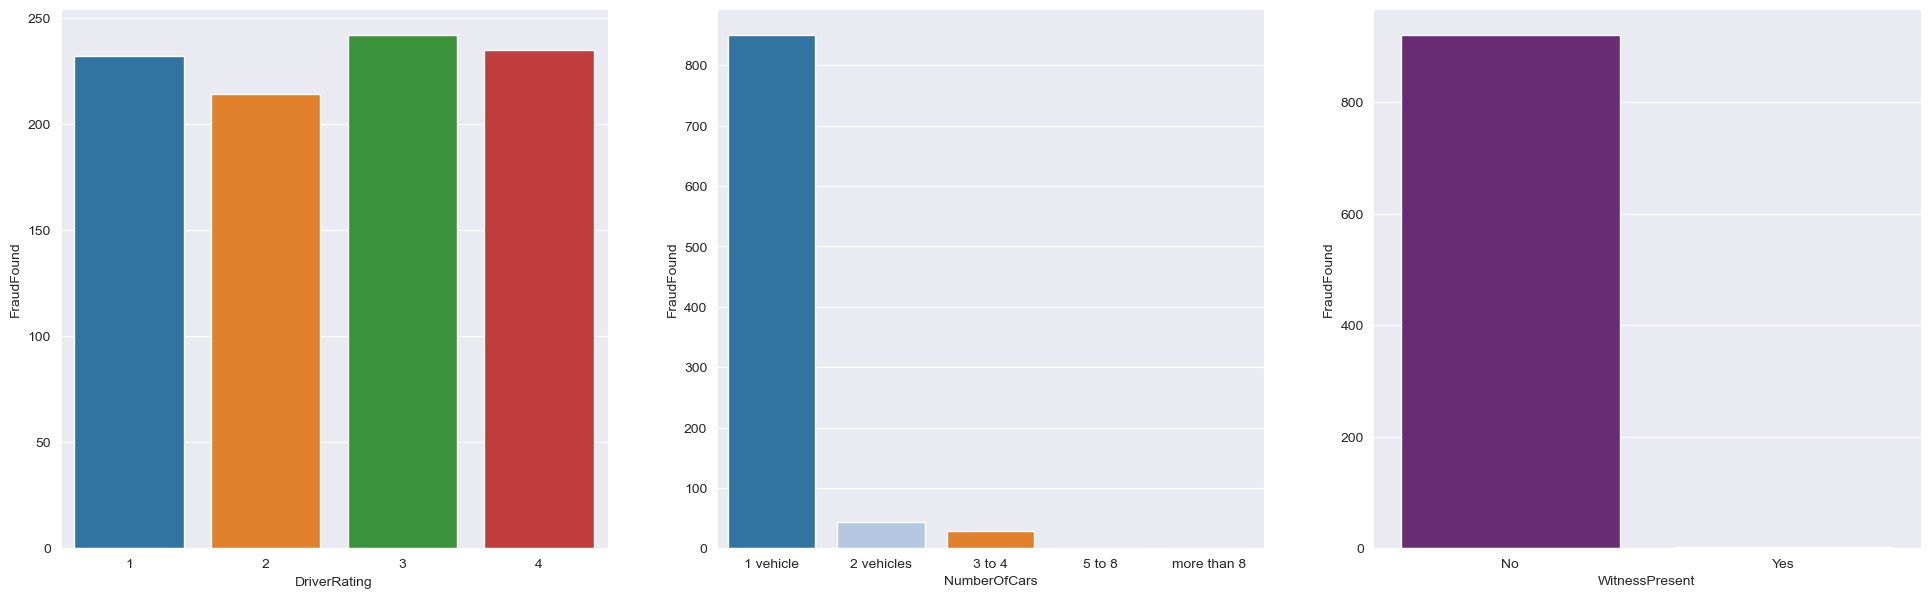

In [174]:
# Let's plot DriverRating, NumberOfCars & WinessPresent with barplot
gpd_val_10 = df.groupby("DriverRating").agg({"FraudFound":"sum"}).reset_index()
gpd_val_11 = df.groupby("NumberOfCars").agg({"FraudFound":"sum"}).reset_index()
gpd_val_12 = df.groupby("WitnessPresent").agg({"FraudFound":"sum"}).reset_index()
fig, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(24,7))

sns.barplot(x="DriverRating", y="FraudFound", data = gpd_val_10, ax= ax1,palette='tab10')
sns.barplot(x="NumberOfCars", y="FraudFound", data = gpd_val_11, ax= ax2,palette='tab20')
sns.barplot(x='WitnessPresent', y='FraudFound', data = gpd_val_12, ax= ax3,palette='magma') 

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\626807032.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="AddressChange_Claim", y="FraudFound", data=gpd_val_12, ax=ax1,palette='tab10')
C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\626807032.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PastNumberOfClaims", y="FraudFound", data=gpd_val_13, ax=ax2,palette='tab10')


<Axes: xlabel='PastNumberOfClaims', ylabel='FraudFound'>

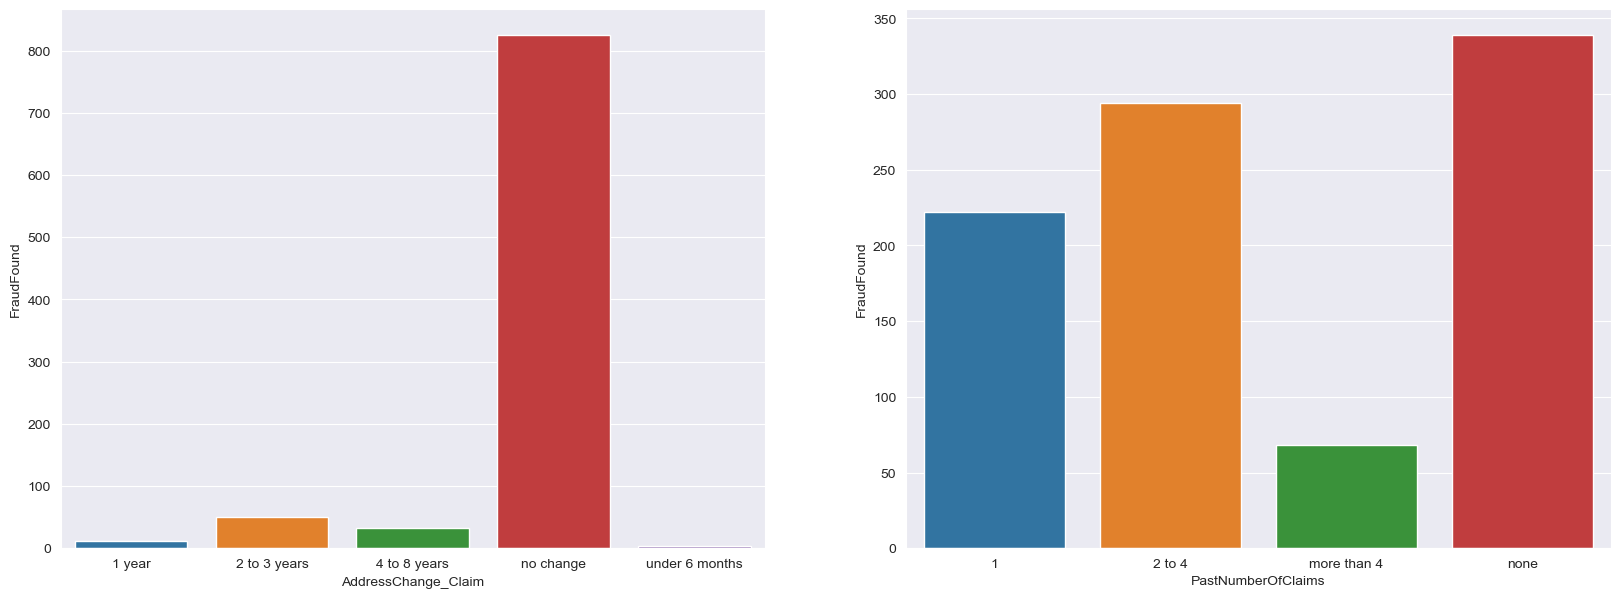

In [175]:
# Let's Plot the AddressChangeClaim & PastNumberOfClaims using Barplot
gpd_val_12 = df.groupby("AddressChange_Claim").agg({"FraudFound": "sum"}).reset_index()
gpd_val_13 = df.groupby("PastNumberOfClaims").agg({"FraudFound": "sum"}).reset_index()

fig , (ax1, ax2) = plt.subplots(1,2, figsize=(20,7))

sns.barplot(x="AddressChange_Claim", y="FraudFound", data=gpd_val_12, ax=ax1,palette='tab10')
sns.barplot(x="PastNumberOfClaims", y="FraudFound", data=gpd_val_13, ax=ax2,palette='tab10')

Exploring the corelation b/w Fraud Cases and Make of the Vehicle

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\1376564691.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Make', y='FraudFound', data = gpd_val1,ax=ax1,palette='tab10')
C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\1376564691.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Make', y='FraudFound', data = gpd_val2,ax=ax2,palette='tab20')


,Make,FraudFound,Total Accidents,Percentage by Make,Percentage by Total
0,Accura,59,472,12.5,0.383
1,BMW,1,15,6.667,0.006
2,Chevrolet,94,1681,5.592,0.61
3,Dodge,2,109,1.835,0.013
4,Ferrari,0,2,0.0,0.0
5,Ford,33,450,7.333,0.214
6,Honda,179,2801,6.391,1.161
7,Jaguar,0,6,0.0,0.0
8,Lexus,0,1,0.0,0.0
9,Mazda,123,2354,5.225,0.798


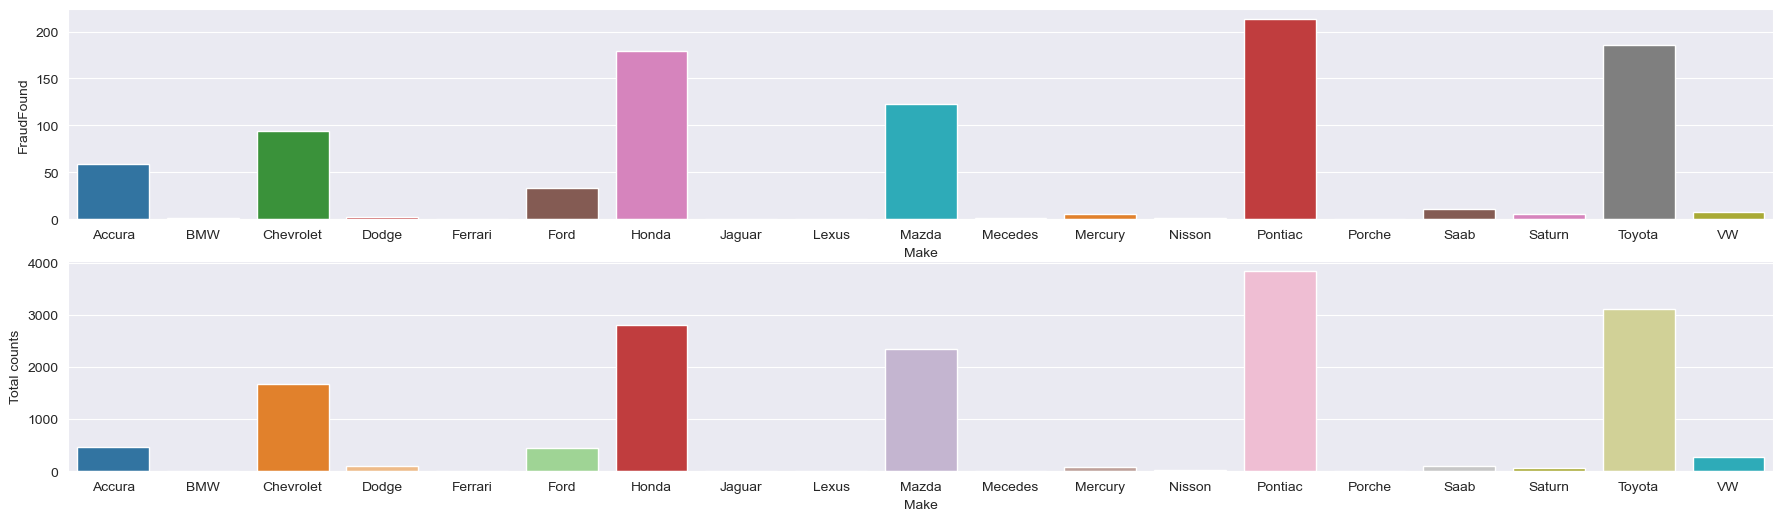

In [176]:
#plotting by FraudFound, looking to see if there are anything obvious that correlates to fraud
gpd_val1=df.groupby('Make').agg({'FraudFound':'sum'}).reset_index()
gpd_val2=df.groupby('Make').agg('count').reset_index()

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(22, 6))
sns.barplot(x='Make', y='FraudFound', data = gpd_val1,ax=ax1,palette='tab10')
sns.barplot(x='Make', y='FraudFound', data = gpd_val2,ax=ax2,palette='tab20')

total_list = pd.concat([gpd_val1, gpd_val2['FraudFound'].rename('Total Accidents')],axis=1)
total_list['Percentage by Make']= round((total_list['FraudFound']/total_list['Total Accidents'])*100,3)
total_list['Percentage by Total'] = round((total_list['FraudFound']/sum(total_list['Total Accidents']))*100,3)

ax2.set(ylabel='Total counts')

data = [['Column total'],
        [sum(total_list['FraudFound'])], 
        [sum(total_list['Total Accidents'])], 
        [sum(total_list['Percentage by Make'])], 
        [sum(total_list['Percentage by Total'])]]

nr = pd.DataFrame(data)

nr1 = nr.transpose()
nr1.rename(columns={0:'Make',1:'FraudFound',2:'Total Accidents',3:'Percentage by Make',4:'Percentage by Total'}, inplace=True)
pd.concat([total_list,nr1],ignore_index=True)

Exploring the corelation b/w Fraud Cases and Marital Status

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\713081536.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MaritalStatus', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')


<Axes: xlabel='MaritalStatus', ylabel='FraudFound'>

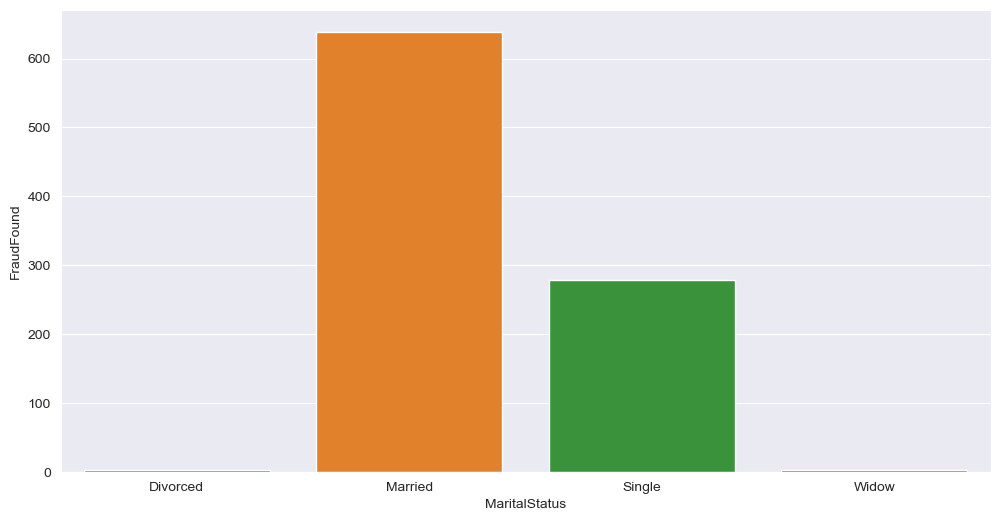

In [177]:
#plotting by FraudFound, looking to see if there are anything obvious that correlates to fraud vs Marital Status
gpd_val1=df.groupby('MaritalStatus').agg({'FraudFound':'sum'}).reset_index()
fig, (ax1) = plt.subplots(1,1,figsize=(12, 6))
sns.barplot(x='MaritalStatus', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')

Exploring the relationship b/w fraud found and Police Report Filed

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\3594455781.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='PoliceReportFiled', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')


<Axes: xlabel='PoliceReportFiled', ylabel='FraudFound'>

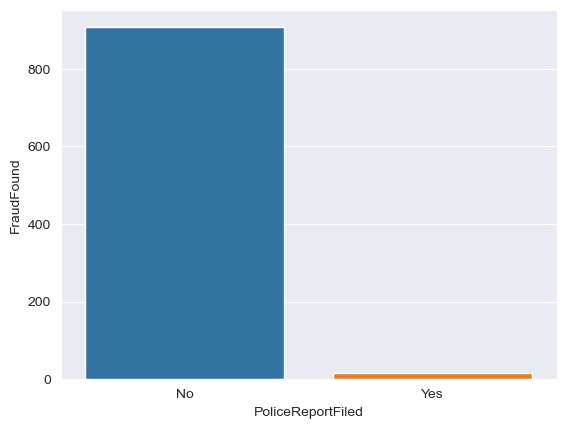

In [178]:
gpd_val1=df.groupby('PoliceReportFiled').agg({'FraudFound':'sum'}).reset_index()

fig, (ax1) = plt.subplots(1)
sns.barplot(x='PoliceReportFiled', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')

Exploring the relationship between fraud found vs Year

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\3684636305.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Year', y='FraudFound', data = gpd_val2, ax=ax2,palette='tab10')


<Axes: xlabel='Year', ylabel='FraudFound'>

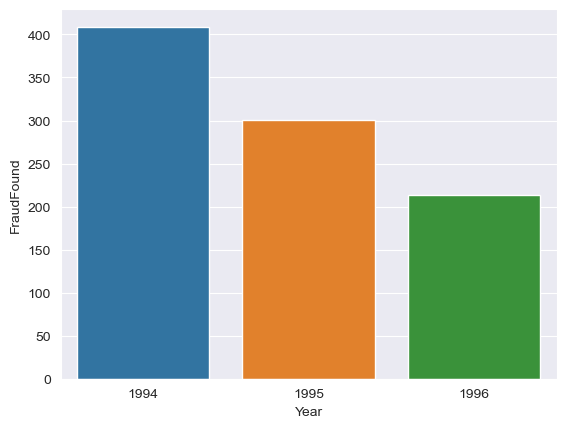

In [179]:
gpd_val2=df.groupby('Year').agg({'FraudFound':'sum'}).reset_index()
fig, (ax2) = plt.subplots(1)
sns.barplot(x='Year', y='FraudFound', data = gpd_val2, ax=ax2,palette='tab10')

Exploring the Relationship b/w Fraud and the Age of the Vehicle

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\838751316.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgeOfVehicle', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')


<Axes: xlabel='AgeOfVehicle', ylabel='FraudFound'>

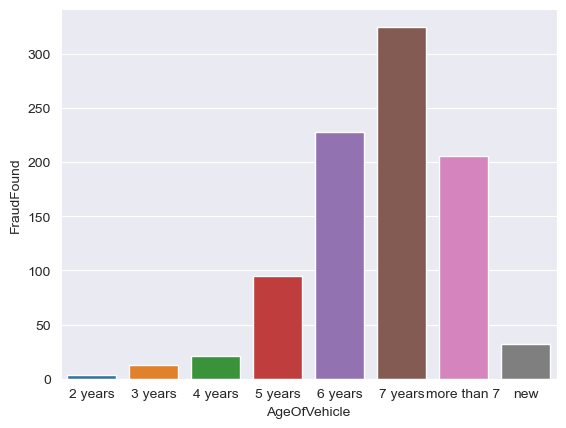

In [180]:
gpd_val1=df.groupby('AgeOfVehicle').agg({'FraudFound':'sum'}).reset_index()

fig, (ax1) = plt.subplots(1)
sns.barplot(x='AgeOfVehicle', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')

Exploring the relationship b/w Fraud and WitnessPresent

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\1038482877.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='WitnessPresent', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab20')


<Axes: xlabel='WitnessPresent', ylabel='FraudFound'>

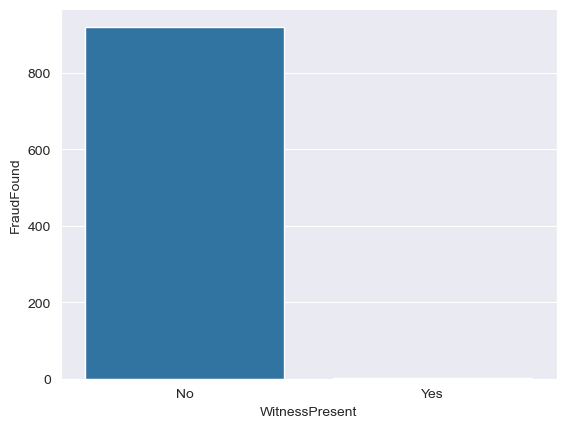

In [181]:
gpd_val1=df.groupby('WitnessPresent').agg({'FraudFound':'sum'}).reset_index()

fig, (ax1) = plt.subplots(1)
sns.barplot(x='WitnessPresent', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab20')

Exploring the relationship between fraud cases and BasePolicy

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\3493216943.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='BasePolicy', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')


<Axes: xlabel='BasePolicy', ylabel='FraudFound'>

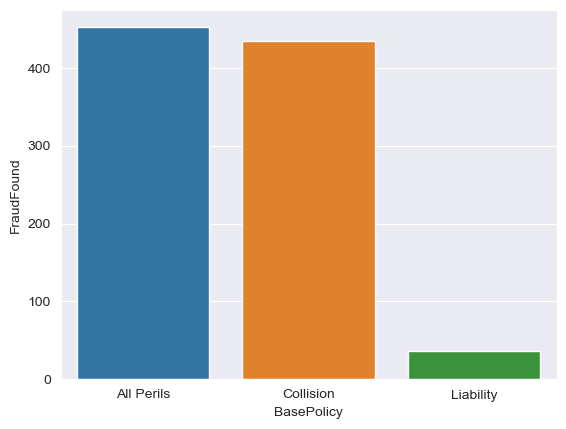

In [182]:
gpd_val1=df.groupby('BasePolicy').agg({'FraudFound':'sum'}).reset_index()

fig, (ax1) = plt.subplots(1)
sns.barplot(x='BasePolicy', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')

Relationship between Fraud Cases and Address Change

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\1236539225.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AddressChange_Claim', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')


<Axes: xlabel='AddressChange_Claim', ylabel='FraudFound'>

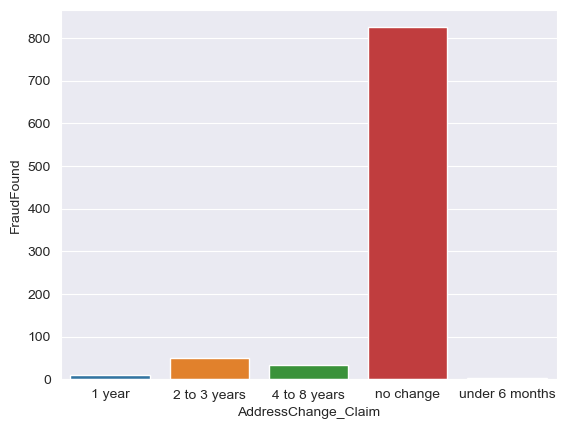

In [183]:
gpd_val1=df.groupby('AddressChange_Claim').agg({'FraudFound':'sum'}).reset_index()

fig, (ax1) = plt.subplots(1)
sns.barplot(x='AddressChange_Claim', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')

Exploring the relationship b/w fraud cases and NumberOfCars

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\1827053346.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NumberOfCars', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')


<Axes: xlabel='NumberOfCars', ylabel='FraudFound'>

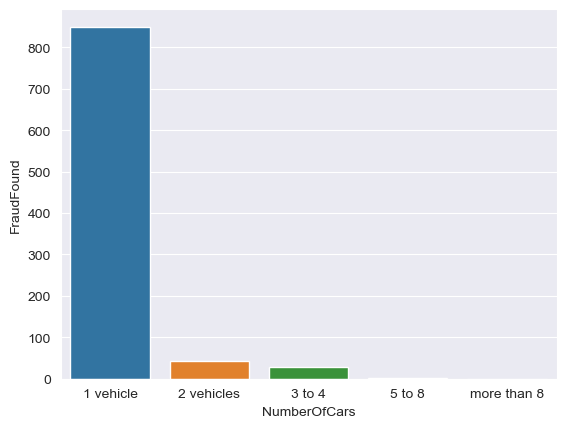

In [184]:
gpd_val1=df.groupby('NumberOfCars').agg({'FraudFound':'sum'}).reset_index()

fig, (ax1) = plt.subplots(1)
sns.barplot(x='NumberOfCars', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')

Relationship b/w fraud cases and AgentType

C:\Users\ashab\AppData\Local\Temp\ipykernel_13384\213733751.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='AgentType', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')


<Axes: xlabel='AgentType', ylabel='FraudFound'>

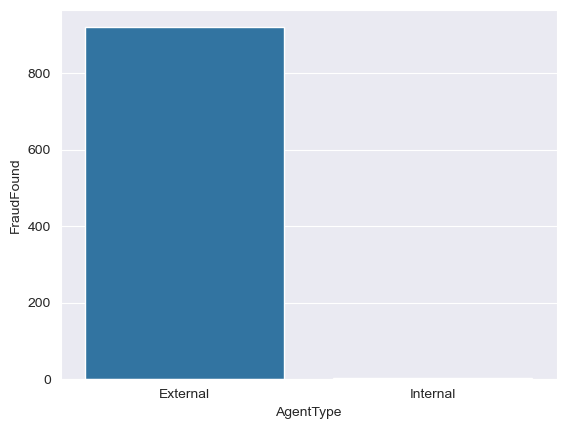

In [185]:
gpd_val1=df.groupby('AgentType').agg({'FraudFound':'sum'}).reset_index()

fig, (ax1) = plt.subplots(1)
sns.barplot(x='AgentType', y='FraudFound', data = gpd_val1, ax=ax1,palette='tab10')

Data Cleaning - Handling Missing Values, null values and dropping duplicates 

In [186]:
#checking for missing values
df.isnull().sum()

Month                   0
WeekOfMonth             0
DayOfWeek               0
Make                    0
AccidentArea            0
DayOfWeekClaimed        0
MonthClaimed            0
WeekOfMonthClaimed      0
Sex                     0
MaritalStatus           0
Age                     0
Fault                   0
PolicyType              0
VehicleCategory         0
VehiclePrice            0
FraudFound              0
PolicyNumber            0
RepNumber               0
Deductible              0
DriverRating            0
Days_Policy_Accident    0
Days_Policy_Claim       0
PastNumberOfClaims      0
AgeOfVehicle            0
AgeOfPolicyHolder       0
PoliceReportFiled       0
WitnessPresent          0
AgentType               0
NumberOfSuppliments     0
AddressChange_Claim     0
NumberOfCars            0
Year                    0
BasePolicy              0
dtype: int64

We donot have any missing values in our dataset, if the missing values were present we can either replace them with
mean for numerical variables or median for categorical variables another approach can be do drop the null values

First, we will look into the 'PolicyNumber'. I suspect that the 'PolicyNumber' is simply the row number minus 1. I can confirm this by summing the policy numbers, and then using the summation identity: sum(i)(for i to n) = n(n+1)/2, where I take n to be the number of rows. If they come out the same then there are no missing or duplicate PolicyNumbers.

In [187]:
print(df['PolicyNumber'].sum())
print((len(df['PolicyNumber'])*(len(df['PolicyNumber']) +1 ))/2 )
df['PolicyNumber']

118895910
118895910.0


0            1
1            2
2            3
3            4
4            5
         ...  
15415    15416
15416    15417
15417    15418
15418    15419
15419    15420
Name: PolicyNumber, Length: 15420, dtype: int64

Lets take care of the 0 in the 'MonthClaimed' and 'DayOfWeekClaimed' features

In [188]:
#Investigate the 0 in DayOfWeekClaimed and MonthClaimed
print('DayOfWeekClaimed has ', len(df.loc[(df['DayOfWeekClaimed']=='0')]), ' row(s) with a 0')
print('MonthClaimed has ',len(df.loc[(df['MonthClaimed']=='0')]),' row(s) with a 0') 
print(' ')

#We see there is only one row where either the DayOfWeekClaimed or MonthClaimed are 0. 
#So now we compare them.
print(df.loc[(df['DayOfWeekClaimed']=='0')])
print(df.loc[(df['MonthClaimed']=='0')])

# Both are zero in the same row (row 1516).

DayOfWeekClaimed has  1  row(s) with a 0
MonthClaimed has  1  row(s) with a 0
 
     Month  WeekOfMonth DayOfWeek   Make AccidentArea DayOfWeekClaimed  \
1516   Jul            2    Monday  Honda        Rural                0   

     MonthClaimed  WeekOfMonthClaimed   Sex MaritalStatus  ...  AgeOfVehicle  \
1516            0                   1  Male        Single  ...           new   

     AgeOfPolicyHolder PoliceReportFiled WitnessPresent AgentType  \
1516          16 to 17                No             No  External   

      NumberOfSuppliments  AddressChange_Claim  NumberOfCars  Year  BasePolicy  
1516                 none            no change     1 vehicle  1994  All Perils  

[1 rows x 33 columns]
     Month  WeekOfMonth DayOfWeek   Make AccidentArea DayOfWeekClaimed  \
1516   Jul            2    Monday  Honda        Rural                0   

     MonthClaimed  WeekOfMonthClaimed   Sex MaritalStatus  ...  AgeOfVehicle  \
1516            0                   1  Male        Single

In [189]:
#lets drop the above row
df = df.drop(index=1516)

We have handled the 0 in the 'DayOfWeekClaimed' and 'MonthClaimed'

In [190]:
#Resets the index on our dataframe,so we can iterate through the rows
#If we didn't do this, attempting to access df.loc[1516] would throw a keyerror
#This suggests that df does not have a row 1516
df.reset_index(drop=True, inplace=True)

In [191]:
#Confirms that there are no Ages equal to 0.
print(df['Age'].unique()==0)
len(df[df['Age']==0])

[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False]


0

Next we are going to check if there are any duplicate rows

In [192]:
#Since the length of the df is the same as the df.drop_duplicates, this tells us
#there are no duplicate rows
print(len(df.drop_duplicates())==len(df))

True


In [197]:
df2=df.copy()
df3=df.copy()

ANOVA Test to identify which variables have a significant impact on the target variable (FraudFound)

In [209]:
from scipy import stats

categorical_features = df.select_dtypes(include=['object']).columns
anova_results = {}

for feature in categorical_features:
    grouped = df.groupby(feature)['FraudFound']
    f_value, p_value = stats.f_oneway(*(group for name, group in grouped))
    anova_results[feature] = {'F-Value': f_value, 'p-Value': p_value}

# Converting results to a DataFrame for better visualization
anova_df = pd.DataFrame(anova_results).T
anova_df['p-Value'] = anova_df['p-Value'].round(5)

# Add significance column
anova_df['Significance'] = np.where(anova_df['p-Value'] < 0.05, '*', '')


# Sort results by F-value and p-value significance level
anova_df = anova_df.sort_values(by=['F-Value', 'Significance'], ascending=[False, True])

print(anova_df)

                         F-Value  p-Value Significance
Fault                 270.870598  0.00000            *
BasePolicy            206.839798  0.00000            *
VehicleCategory       148.260040  0.00000            *
PolicyType             56.250528  0.00000            *
AddressChange_Claim    26.351155  0.00000            *
PastNumberOfClaims     17.904795  0.00000            *
AccidentArea           17.380305  0.00003            *
Sex                    13.851336  0.00020            *
VehiclePrice           13.621873  0.00000            *
AgentType               8.145948  0.00432            *
NumberOfSuppliments     6.057405  0.00041            *
AgeOfPolicyHolder       4.144591  0.00006            *
PoliceReportFiled       3.952788  0.04681            *
MonthClaimed            3.843945  0.00001            *
Make                    3.331902  0.00000            *
AgeOfVehicle            3.145019  0.00254            *
Days_Policy_Accident    2.893694  0.02084            *
Month     

ANOVA test results indicate that multiple features such as Fault, PolicyType, BasePolicy, and VehicleCategory are highly statistically significant (p < 0.001), suggesting strong association with fraud occurrence. However, variables such as MaritalStatus and NumberOfCars show no significant relationship and may be excluded from model training to reduce noise and improve generalization

We decided to drop the Age and Policy Number columns since PolicyNumber is just a number and have no significant impact on our
model and Age of Policy Holder is present so do not need an additional age column

In [198]:
#Final Dataset for Training 
df_fraud=df2.drop(['Age', 'PolicyNumber'], axis=1)

In [200]:
df_fraud.columns

Index(['Month', 'WeekOfMonth', 'DayOfWeek', 'Make', 'AccidentArea',
       'DayOfWeekClaimed', 'MonthClaimed', 'WeekOfMonthClaimed', 'Sex',
       'MaritalStatus', 'Fault', 'PolicyType', 'VehicleCategory',
       'VehiclePrice', 'FraudFound', 'RepNumber', 'Deductible', 'DriverRating',
       'Days_Policy_Accident', 'Days_Policy_Claim', 'PastNumberOfClaims',
       'AgeOfVehicle', 'AgeOfPolicyHolder', 'PoliceReportFiled',
       'WitnessPresent', 'AgentType', 'NumberOfSuppliments',
       'AddressChange_Claim', 'NumberOfCars', 'Year', 'BasePolicy'],
      dtype='object')

In [201]:
def column_to_dummy_vars(dataframe, column_name):
    dummies = pd.get_dummies(dataframe[column_name], prefix=f"{column_name} = ")
    dataframe = pd.concat([dataframe, dummies], axis=1)
    dataframe = dataframe.drop([column_name], axis=1)
    return dataframe

In [202]:
#apply the function above to all columns that have cateogorical data
for col in df_fraud:
     if df_fraud[col].dtype == 'object':

        df_fraud = column_to_dummy_vars(df_fraud, col)

In [204]:
pd.DataFrame(df_fraud['FraudFound'].value_counts())

,count
FraudFound,
0,14496
1,923


In [205]:
df_fraud.columns

Index(['WeekOfMonth', 'WeekOfMonthClaimed', 'FraudFound', 'RepNumber',
       'Deductible', 'DriverRating', 'Year', 'Month = _Apr', 'Month = _Aug',
       'Month = _Dec',
       ...
       'AddressChange_Claim = _no change',
       'AddressChange_Claim = _under 6 months', 'NumberOfCars = _1 vehicle',
       'NumberOfCars = _2 vehicles', 'NumberOfCars = _3 to 4',
       'NumberOfCars = _5 to 8', 'NumberOfCars = _more than 8',
       'BasePolicy = _All Perils', 'BasePolicy = _Collision',
       'BasePolicy = _Liability'],
      dtype='object', length=144)

In [194]:
#X=df.drop('FraudFound',axis=1).copy()
#y=df['FraudFound'].copy()
pd.concat([X, y], axis=1)

,WeekOfMonth,WeekOfMonthClaimed,RepNumber,Deductible,DriverRating,Year,Month = _Apr,Month = _Aug,Month = _Dec,Month = _Feb,...,AddressChange_Claim = _under 6 months,NumberOfCars = _1 vehicle,NumberOfCars = _2 vehicles,NumberOfCars = _3 to 4,NumberOfCars = _5 to 8,NumberOfCars = _more than 8,BasePolicy = _All Perils,BasePolicy = _Collision,BasePolicy = _Liability,FraudFound
0,5,1,12,300,1,1994,False,False,True,False,...,False,False,False,True,False,False,False,False,True,0
1,3,4,15,400,4,1994,False,False,False,False,...,False,True,False,False,False,False,False,True,False,0
2,5,2,7,400,3,1994,False,False,False,False,...,False,True,False,False,False,False,False,True,False,0
3,2,1,4,400,2,1994,False,False,False,False,...,False,True,False,False,False,False,False,False,True,0
4,5,2,3,400,1,1994,False,False,False,False,...,False,True,False,False,False,False,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15414,4,5,5,400,4,1996,False,False,False,False,...,False,True,False,False,False,False,False,True,False,1
15415,5,1,11,400,3,1996,False,False,False,False,...,False,False,False,True,False,False,False,False,True,0
15416,5,1,4,400,4,1996,False,False,False,False,...,False,True,False,False,False,False,False,True,False,1
15417,1,2,6,400,4,1996,False,False,True,False,...,False,True,False,False,False,False,True,False,False,0


In [206]:
# splitting the dataset
from sklearn.model_selection import train_test_split

# Separating features and target variable
X = df_fraud.drop('FraudFound', axis=1)
y = df_fraud['FraudFound']

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [207]:
# Logistic regression - baseline with no data sampling mathod applied, to have a 
# comparison point 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create a Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the balanced dataset
logreg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lg = logreg_model.predict(X_test)

# Evaluate the performance of the model
conf_matrix = confusion_matrix(y_test, y_pred_lg)
classification_rep = classification_report(y_test, y_pred_lg)

# Print the results
print("\nConfusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", classification_rep)


Confusion Matrix:
 [[2890    9]
 [ 183    2]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.18      0.01      0.02       185

    accuracy                           0.94      3084
   macro avg       0.56      0.50      0.49      3084
weighted avg       0.89      0.94      0.91      3084



C:\Users\ashab\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


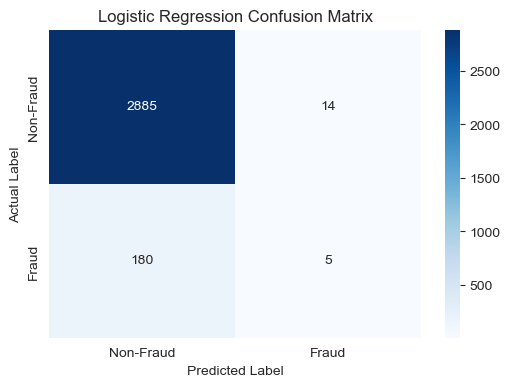

In [214]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Logistic Regression Confusion Matrix')

plt.show()

Decision Tree

In [208]:
# Decision Tree basic- baseline with no data sampling mathod applied, to have a 
# comparison point 

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create a Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the SMOTE dataset
dt_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the performance of the model
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
classification_rep_dt = classification_report(y_test, y_pred_dt)

# Print the results
print("\nDecision Tree Confusion Matrix:\n", conf_matrix_dt)
print("\nDecision Tree Classification Report:\n", classification_rep_dt)


Decision Tree Confusion Matrix:
 [[2723  176]
 [ 137   48]]

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.94      0.95      2899
           1       0.21      0.26      0.23       185

    accuracy                           0.90      3084
   macro avg       0.58      0.60      0.59      3084
weighted avg       0.91      0.90      0.90      3084



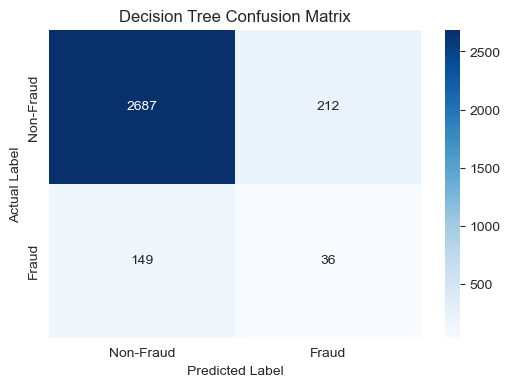

In [215]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Plot heatmap
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Decision Tree Confusion Matrix')

plt.show()

To Solve the class imbalance problem in our dataset, we will use SMOTE technique and then we will compare the model results 
with the baseline model

In [210]:
# Applying SMOTE to oversample the minority class cases:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [211]:
y_train_smote.value_counts()

FraudFound
1    11597
0    11597
Name: count, dtype: int64

Now our dataset is perfectly balanced with equal number of fraud and genuine cases

Logistic Regression with SMOTE

In [212]:
# Logistic Regression after applying SMOTE:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create a Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on the balanced dataset
logreg_model.fit(X_train_smote, y_train_smote)

# Make predictions on the test set
y_pred = logreg_model.predict(X_test)

# Evaluate the performance of the model
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

# Print the results
print("\nConfusion Matrix:\n", conf_matrix)Confusion Matrix:
 [[2885   14]
 [ 180    5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.26      0.03      0.05       185

    accuracy                           0.94      3084
   macro avg       0.60      0.51      0.51      3084
weighted avg       0.90      0.94      0.91      3084

print("\nClassification Report:\n", classification_rep)


Confusion Matrix:
 [[2885   14]
 [ 180    5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.26      0.03      0.05       185

    accuracy                           0.94      3084
   macro avg       0.60      0.51      0.51      3084
weighted avg       0.90      0.94      0.91      3084



C:\Users\ashab\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


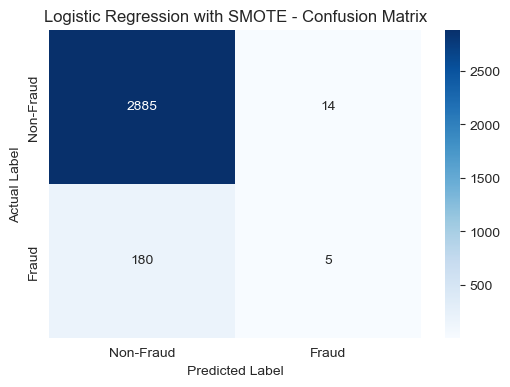

In [217]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create heatmap
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Logistic Regression with SMOTE - Confusion Matrix')

plt.show()

Decision Tree with SMOTE

In [213]:
# Decision Tree after SMOTE:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Create a Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the SMOTE dataset
dt_model.fit(X_train_smote, y_train_smote)

# Make predictions on the test set
y_pred_dt = dt_model.predict(X_test)

# Evaluate the performance of the model
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
classification_rep_dt = classification_report(y_test, y_pred_dt)

# Print the results
print("\nDecision Tree Confusion Matrix:\n", conf_matrix_dt)
print("\nDecision Tree Classification Report:\n", classification_rep_dt)


Decision Tree Confusion Matrix:
 [[2687  212]
 [ 149   36]]

Decision Tree Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      2899
           1       0.15      0.19      0.17       185

    accuracy                           0.88      3084
   macro avg       0.55      0.56      0.55      3084
weighted avg       0.90      0.88      0.89      3084



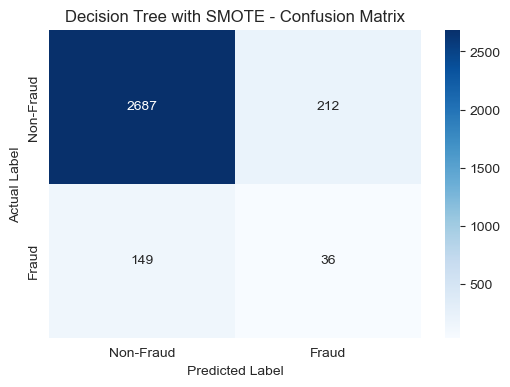

In [219]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Plot heatmap
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Fraud', 'Fraud'],
    yticklabels=['Non-Fraud', 'Fraud']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Decision Tree with SMOTE - Confusion Matrix')

plt.show()